In [1]:
# Install required packages
!pip install -q pycocotools torchvision

import os
import json
import zipfile
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from google.colab import files

import torch
import torchvision
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader

print(f'PyTorch version : {torch.__version__}')
print(f'Torchvision     : {torchvision.__version__}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device          : {DEVICE}')


PyTorch version : 2.10.0+cu128
Torchvision     : 0.25.0+cu128
Device          : cuda


In [2]:
# ── Upload ZIP ──────────────────────────────────────────────────────────────
print('Please upload your dataset ZIP file...')
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]
print(f'Uploaded: {zip_filename}')

# ── Extract ──────────────────────────────────────────────────────────────────
EXTRACT_DIR = '/content/dataset'
os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(zip_filename, 'r') as zf:
    zf.extractall(EXTRACT_DIR)
print('Extraction complete. Directory tree:')
for root, dirs, fnames in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        for f in fnames[:5]:
            print(f'{indent}  {f}')

Please upload your dataset ZIP file...


Saving helmet.v2i.coco.zip to helmet.v2i.coco.zip
Uploaded: helmet.v2i.coco.zip
Extraction complete. Directory tree:
dataset/
  README.roboflow.txt
  train/
    Is-Guvenligi-Baretleri-Kafa-Koruyucular-ProPaza_jpg.rf.520c2354e65d88c3b7a76d323083035e.jpg
    worker_5_mp4-0358_jpg.rf.762c2213766ea099bdfcae5abc0afbfd.jpg
    2_0_16044888_jpg.rf.29ff87ad10433cbcccf80780a8a332a8.jpg
    2_0_92142907_jpg.rf.1e48dadd6429ec7df6c0ed16f9ea8778.jpg
    ppe_0369_jpg.rf.919f8639c704194a428543b13929bcf5.jpg
  test/
    Tan0639639_jpg.rf.98a7f9b6e83ed3a5d76207bafe670882.jpg
    0_90497142_jpg.rf.23efeaa8a3e8ebb42fdab847b239adb1.jpg
    2_0_86778861_jpg.rf.b74270c62380cba76639b28bdb035902.jpg
    0_86004889_jpg.rf.a7b5abf422b797b44990adce07d5b9eb.jpg
    ppe_1212_jpg.rf.838f5a4a500e04af0949942d3b22913a.jpg
  valid/
    ppe_0283_jpg.rf.b8490f54fb2d29fa07d55348d42fc1f6.jpg
    1_65111090_jpg.rf.7456d545f53680a9f90b62821f62a3c7.jpg
    ppe_0139_jpg.rf.6a269822d55759fdc6db8b31336beeea.jpg
    ppe_0451_jpg.

In [3]:
# ── Auto-detect annotation format ───────────────────────────────────────────
def find_images_dir(base):
    for root, dirs, files_ in os.walk(base):
        for d in dirs:
            if d.lower() in ('images', 'imgs', 'image'):
                return os.path.join(root, d)
    return base

def find_labels_dir(base):
    for root, dirs, files_ in os.walk(base):
        for d in dirs:
            if d.lower() in ('labels', 'annotations', 'label'):
                return os.path.join(root, d)
    return None

def find_coco_json(base):
    for root, dirs, files_ in os.walk(base):
        for f in files_:
            if f.endswith('.json'):
                return os.path.join(root, f)
    return None

IMG_DIR    = find_images_dir(EXTRACT_DIR)
LABELS_DIR = find_labels_dir(EXTRACT_DIR)
COCO_JSON  = find_coco_json(EXTRACT_DIR)

FORMAT = 'coco' if COCO_JSON else 'yolo'
print(f'Detected format : {FORMAT}')
print(f'Images dir      : {IMG_DIR}')
if FORMAT == 'coco':
    print(f'COCO JSON       : {COCO_JSON}')
else:
    print(f'Labels dir      : {LABELS_DIR}')

Detected format : coco
Images dir      : /content/dataset
COCO JSON       : /content/dataset/train/_annotations.coco.json


In [4]:
class CustomDetectionDataset(Dataset):
    """
    Supports COCO JSON and YOLO TXT annotation formats.
    Returns (image_tensor, target_dict) compatible with torchvision Faster R-CNN.
    """

    def __init__(self, img_dir, fmt='coco', coco_json=None,
                 labels_dir=None, transforms=None):
        self.img_dir    = img_dir
        self.fmt        = fmt
        self.transforms = transforms
        self.items      = []   # list of (img_path, boxes, labels)

        img_exts = ('.jpg', '.jpeg', '.png', '.bmp')

        if fmt == 'coco':
            with open(coco_json) as f:
                coco = json.load(f)
            id2file = {img['id']: img['file_name'] for img in coco['images']}
            id2anns = {img['id']: [] for img in coco['images']}
            for ann in coco['annotations']:
                id2anns[ann['image_id']].append(ann)
            for img_id, img_file in id2file.items():
                # resolve path
                candidate = os.path.join(img_dir, os.path.basename(img_file))
                if not os.path.exists(candidate):
                    candidate = os.path.join(img_dir, img_file)
                if not os.path.exists(candidate):
                    continue
                boxes, lbls = [], []
                for ann in id2anns[img_id]:
                    x, y, w, h = ann['bbox']
                    boxes.append([x, y, x + w, y + h])
                    lbls.append(ann['category_id'])
                if boxes:
                    self.items.append((candidate, boxes, lbls))

        else:  # YOLO format
            img_paths = sorted([
                os.path.join(img_dir, f)
                for f in os.listdir(img_dir)
                if f.lower().endswith(img_exts)
            ])
            for ip in img_paths:
                stem = os.path.splitext(os.path.basename(ip))[0]
                lp   = os.path.join(labels_dir, stem + '.txt') if labels_dir else None
                boxes, lbls = [], []
                if lp and os.path.exists(lp):
                    img_pil = Image.open(ip)
                    W, H    = img_pil.size
                    with open(lp) as f:
                        for line in f:
                            parts = line.strip().split()
                            if len(parts) != 5:
                                continue
                            cls, cx, cy, bw, bh = map(float, parts)
                            x1 = (cx - bw / 2) * W
                            y1 = (cy - bh / 2) * H
                            x2 = (cx + bw / 2) * W
                            y2 = (cy + bh / 2) * H
                            boxes.append([x1, y1, x2, y2])
                            lbls.append(int(cls) + 1)  # 0 reserved for background
                if boxes:
                    self.items.append((ip, boxes, lbls))
                else:
                    # include images without annotations (for inference)
                    self.items.append((ip, [], []))

        print(f'Dataset loaded: {len(self.items)} images with annotations.')

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, boxes, lbls = self.items[idx]
        image = Image.open(img_path).convert('RGB')

        target = {}
        if boxes:
            target['boxes']  = torch.as_tensor(boxes, dtype=torch.float32)
            target['labels'] = torch.as_tensor(lbls,  dtype=torch.int64)
        else:
            target['boxes']  = torch.zeros((0, 4), dtype=torch.float32)
            target['labels'] = torch.zeros((0,),   dtype=torch.int64)

        target['image_id'] = torch.tensor([idx])

        if self.transforms:
            image = self.transforms(image)
        else:
            image = transforms.ToTensor()(image)

        return image, target

print('CustomDetectionDataset class defined.')


CustomDetectionDataset class defined.


In [6]:
import os

# ── User config — edit NUM_CLASSES to match your dataset ────────────────────
# NUM_CLASSES = number_of_object_classes + 1  (background)
NUM_CLASSES = 2   # e.g. 1 class + background
BATCH_SIZE  = 2
NUM_EPOCHS  = 5
LR          = 0.005

# Fix for image directory. The COCO_JSON is for the 'train' split,
# so IMG_DIR should point to the 'train' folder.
IMG_DIR = os.path.dirname(COCO_JSON)

# ── Data augmentation / transforms ──────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
])

# ── Build dataset ─────────────────────────────────────────────────────────
full_dataset = CustomDetectionDataset(
    img_dir    = IMG_DIR,
    fmt        = FORMAT,
    coco_json  = COCO_JSON,
    labels_dir = LABELS_DIR,
    transforms = None          # assigned after split
)

# 80 / 20 train-val split
n_total  = len(full_dataset)
n_train  = int(0.8 * n_total)
n_val    = n_total - n_train
train_ds, val_ds = torch.utils.data.random_split(full_dataset, [n_train, n_val])

# apply transforms post-split
train_ds.dataset.transforms = train_transforms
val_ds.dataset.transforms   = val_transforms

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn)

print(f'Train samples : {n_train}')
print(f'Val samples   : {n_val}')

Dataset loaded: 228 images with annotations.
Train samples : 182
Val samples   : 46


In [7]:
def build_faster_rcnn(num_classes):
    """
    Load a pretrained Faster R-CNN (ResNet-50 + FPN) and replace
    the box predictor head to match num_classes.
    """
    model = fasterrcnn_resnet50_fpn(weights='DEFAULT')

    # Replace the classification + regression head
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

model = build_faster_rcnn(NUM_CLASSES).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 160MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [8]:
#%% md
## Step 6 — Optimizer & LR Scheduler
#%%
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LR, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
print('Optimizer and scheduler ready.')

Optimizer and scheduler ready.


  Epoch [1/5] Batch [5/91] Loss: 0.3447
  Epoch [1/5] Batch [10/91] Loss: 0.3093
  Epoch [1/5] Batch [15/91] Loss: 0.2002
  Epoch [1/5] Batch [20/91] Loss: 0.3146
  Epoch [1/5] Batch [25/91] Loss: 0.2529
  Epoch [1/5] Batch [30/91] Loss: 0.2120
  Epoch [1/5] Batch [35/91] Loss: 0.0942
  Epoch [1/5] Batch [40/91] Loss: 0.1490
  Epoch [1/5] Batch [45/91] Loss: 0.3132
  Epoch [1/5] Batch [50/91] Loss: 0.1364
  Epoch [1/5] Batch [55/91] Loss: 0.0386
  Epoch [1/5] Batch [60/91] Loss: 0.2616
  Epoch [1/5] Batch [65/91] Loss: 0.1173
  Epoch [1/5] Batch [70/91] Loss: 0.1338
  Epoch [1/5] Batch [75/91] Loss: 0.2639
  Epoch [1/5] Batch [80/91] Loss: 0.2300
  Epoch [1/5] Batch [85/91] Loss: 0.1013
  Epoch [1/5] Batch [90/91] Loss: 0.1875
Epoch [1/5] Avg Loss: 0.2339
  Epoch [2/5] Batch [5/91] Loss: 0.1015
  Epoch [2/5] Batch [10/91] Loss: 0.0883
  Epoch [2/5] Batch [15/91] Loss: 0.1297
  Epoch [2/5] Batch [20/91] Loss: 0.1546
  Epoch [2/5] Batch [25/91] Loss: 0.1290
  Epoch [2/5] Batch [30/91] Lo

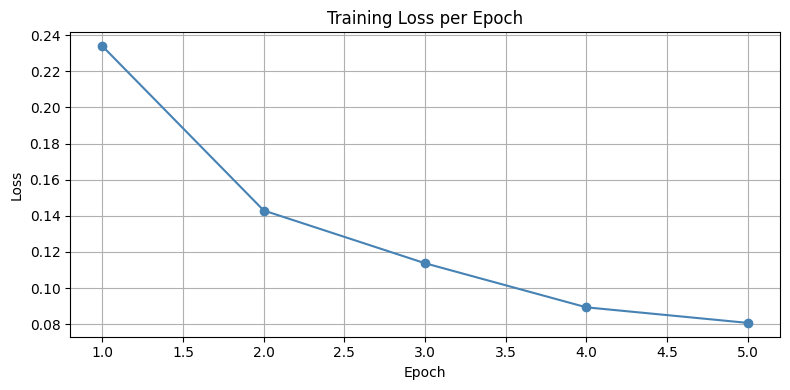

Training complete.


In [9]:
train_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0

    for batch_idx, (images, targets) in enumerate(train_loader):
        images  = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        # Skip samples without any boxes
        valid = [i for i, t in enumerate(targets) if t['boxes'].shape[0] > 0]
        if not valid:
            continue
        images  = [images[i]  for i in valid]
        targets = [targets[i] for i in valid]

        loss_dict = model(images, targets)
        losses    = sum(loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

        if (batch_idx + 1) % 5 == 0:
            print(f'  Epoch [{epoch+1}/{NUM_EPOCHS}] '
                  f'Batch [{batch_idx+1}/{len(train_loader)}] '
                  f'Loss: {losses.item():.4f}')

    lr_scheduler.step()
    avg = epoch_loss / max(len(train_loader), 1)
    train_losses.append(avg)
    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] Avg Loss: {avg:.4f}')

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, marker='o', color='steelblue')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/training_loss.png', dpi=150)
plt.show()
print('Training complete.')

In [10]:
def calculate_iou(box1, box2):
    """
    Compute IoU between two boxes [x1, y1, x2, y2].
    """
    inter_x1 = max(box1[0], box2[0])
    inter_y1 = max(box1[1], box2[1])
    inter_x2 = min(box1[2], box2[2])
    inter_y2 = min(box1[3], box2[3])

    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    area1      = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2      = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = area1 + area2 - inter_area

    return inter_area / union_area if union_area > 0 else 0.0

# Quick test
b1 = [0.1, 0.1, 0.4, 0.4]
b2 = [0.12, 0.12, 0.42, 0.42]
print(f'Test IoU: {calculate_iou(b1, b2):.4f}  (expected ~0.73)')

Test IoU: 0.7717  (expected ~0.73)


In [11]:
def calculate_precision_recall(pred_boxes, pred_scores, pred_labels,
                                gt_boxes,   gt_labels,
                                iou_threshold=0.5):
    tp, fp   = 0, 0
    matched_gt = set()

    # Sort by confidence descending
    order = np.argsort(-np.array(pred_scores))

    for i in order:
        pred_box   = pred_boxes[i]
        pred_label = pred_labels[i]

        best_iou, best_gt_idx = 0, -1
        for j, gt_box in enumerate(gt_boxes):
            if gt_labels[j] == pred_label and j not in matched_gt:
                iou = calculate_iou(pred_box, gt_box)
                if iou > best_iou:
                    best_iou      = iou
                    best_gt_idx   = j

        if best_iou >= iou_threshold:
            tp += 1
            matched_gt.add(best_gt_idx)
        else:
            fp += 1

    fn        = len(gt_boxes) - len(matched_gt)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return precision, recall

print('Precision-Recall function defined.')

Precision-Recall function defined.


In [12]:
def calculate_ap(precisions, recalls):
    """Interpolated AP using rectangular integration."""
    precisions = [0.0] + list(precisions) + [0.0]
    recalls    = [0.0] + list(recalls)    + [1.0]

    # Make precision monotonically decreasing
    for i in range(len(precisions) - 2, -1, -1):
        precisions[i] = max(precisions[i], precisions[i + 1])

    indices = [i for i in range(1, len(recalls))
               if recalls[i] != recalls[i - 1]]
    ap = sum((recalls[i] - recalls[i - 1]) * precisions[i]
             for i in indices)
    return ap


def calculate_map(predictions, ground_truths, num_classes,
                  iou_threshold=0.5):
    """
    predictions  : list of dicts {'boxes': [...], 'scores': [...], 'labels': [...]}
    ground_truths: list of dicts {'boxes': [...], 'labels': [...]}
    """
    average_precisions = []

    for class_id in range(1, num_classes):          # skip background (0)
        all_precisions, all_recalls = [], []

        for pred, gt in zip(predictions, ground_truths):
            p_boxes  = [b for b, l in zip(pred['boxes'],  pred['labels'])  if l == class_id]
            p_scores = [s for s, l in zip(pred['scores'], pred['labels'])  if l == class_id]
            g_boxes  = [b for b, l in zip(gt['boxes'],    gt['labels'])    if l == class_id]
            g_labels = [class_id] * len(g_boxes)

            if not p_boxes and not g_boxes:
                continue

            prec, rec = calculate_precision_recall(
                p_boxes, p_scores, [class_id] * len(p_boxes),
                g_boxes, g_labels, iou_threshold
            )
            all_precisions.append(prec)
            all_recalls.append(rec)

        if all_precisions:
            ap = calculate_ap(all_precisions, all_recalls)
            average_precisions.append(ap)
            print(f'  Class {class_id}: AP = {ap:.4f}')

    mAP = np.mean(average_precisions) if average_precisions else 0.0
    return mAP

print('AP & mAP functions defined.')


AP & mAP functions defined.


In [13]:
SCORE_THRESHOLD = 0.5

model.eval()
all_predictions   = []
all_ground_truths = []

with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(DEVICE) for img in images]
        outputs = model(images)

        for out, tgt in zip(outputs, targets):
            keep = out['scores'] >= SCORE_THRESHOLD
            all_predictions.append({
                'boxes' : out['boxes'][keep].cpu().tolist(),
                'scores': out['scores'][keep].cpu().tolist(),
                'labels': out['labels'][keep].cpu().tolist(),
            })
            all_ground_truths.append({
                'boxes' : tgt['boxes'].cpu().tolist(),
                'labels': tgt['labels'].cpu().tolist(),
            })

print('Running mAP calculation...')
mAP = calculate_map(all_predictions, all_ground_truths,
                    NUM_CLASSES, iou_threshold=0.5)
print(f'\nMean Average Precision (mAP@0.5): {mAP:.4f}')

Running mAP calculation...
  Class 1: AP = 1.0000

Mean Average Precision (mAP@0.5): 1.0000


/tmp/ipykernel_868/2313745257.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colours = plt.cm.get_cmap('tab10', NUM_CLASSES)


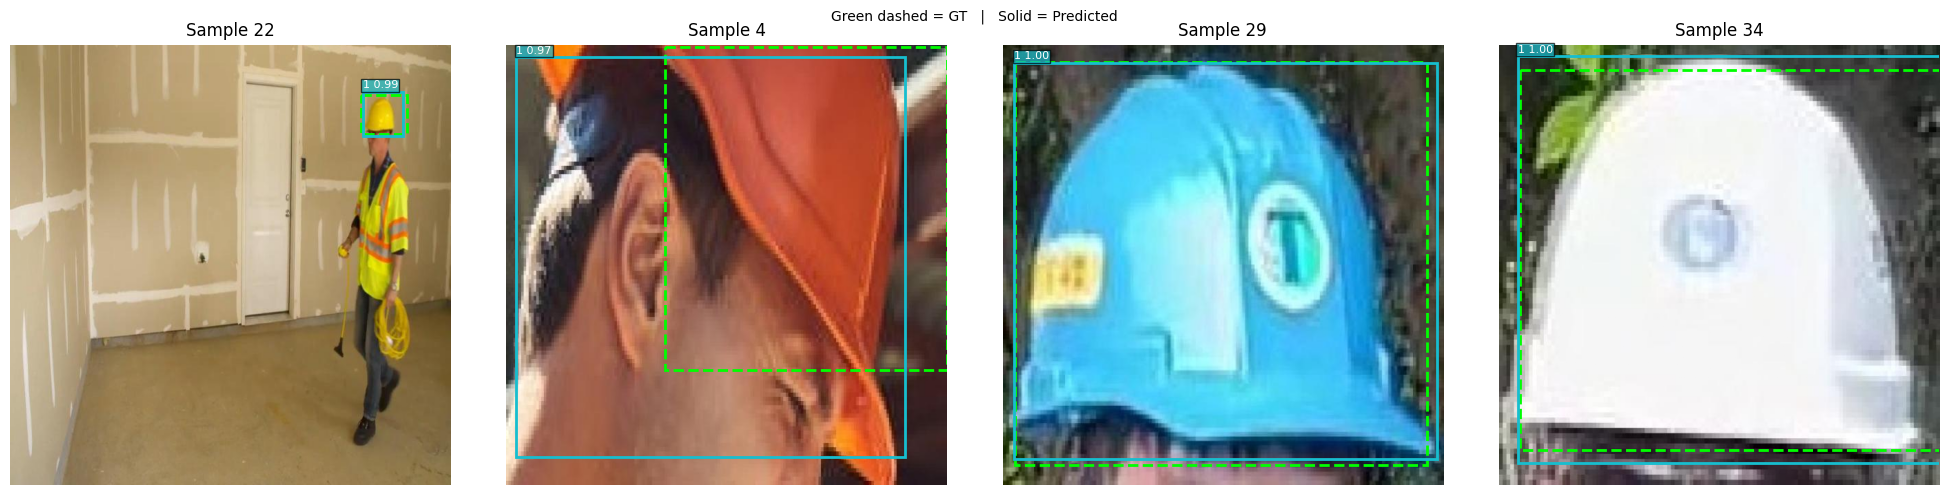

In [14]:
def visualise_predictions(model, dataset, device, num_images=4,
                          score_thresh=0.4, class_names=None):
    model.eval()
    indices = random.sample(range(len(dataset)), min(num_images, len(dataset)))

    fig, axes = plt.subplots(1, len(indices), figsize=(5 * len(indices), 5))
    if len(indices) == 1:
        axes = [axes]

    colours = plt.cm.get_cmap('tab10', NUM_CLASSES)

    for ax, idx in zip(axes, indices):
        image, target = dataset[idx]
        with torch.no_grad():
            out = model([image.to(device)])[0]

        img_np = image.permute(1, 2, 0).cpu().numpy()
        ax.imshow(img_np)

        # Draw GT boxes (green dashed)
        for box, lbl in zip(target['boxes'].tolist(), target['labels'].tolist()):
            x1, y1, x2, y2 = box
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                      linewidth=2, edgecolor='lime',
                                      facecolor='none', linestyle='--')
            ax.add_patch(rect)

        # Draw predicted boxes (colour-coded)
        for box, score, lbl in zip(out['boxes'].tolist(),
                                   out['scores'].tolist(),
                                   out['labels'].tolist()):
            if score < score_thresh:
                continue
            x1, y1, x2, y2 = box
            colour = colours(lbl % NUM_CLASSES)
            rect   = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                        linewidth=2, edgecolor=colour,
                                        facecolor='none')
            ax.add_patch(rect)
            name = class_names[lbl] if class_names and lbl < len(class_names) else str(lbl)
            ax.text(x1, y1 - 5, f'{name} {score:.2f}',
                    color='white', fontsize=8,
                    bbox=dict(facecolor=colour, alpha=0.7, pad=1))

        ax.axis('off')
        ax.set_title(f'Sample {idx}')

    plt.suptitle('Green dashed = GT   |   Solid = Predicted', fontsize=10)
    plt.tight_layout()
    plt.savefig('/content/predictions_visualised.png', dpi=150)
    plt.show()

# Provide class names if known, otherwise leave as None
CLASS_NAMES = None  # e.g. ['background', 'cat', 'dog']
visualise_predictions(model, val_ds, DEVICE, num_images=4,
                      class_names=CLASS_NAMES)

In [15]:
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def build_faster_rcnn_mobilenet(num_classes):
    model = fasterrcnn_mobilenet_v3_large_fpn(weights='DEFAULT')
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

light_model = build_faster_rcnn_mobilenet(NUM_CLASSES).to(DEVICE)
total_params_light = sum(p.numel() for p in light_model.parameters() if p.requires_grad)
total_params_heavy = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'ResNet-50 FPN  params : {total_params_heavy:>12,}')
print(f'MobileNetV3 FPN params: {total_params_light:>12,}')
print('MobileNet is significantly smaller — faster inference on limited hardware.')

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


100%|██████████| 74.2M/74.2M [00:01<00:00, 55.0MB/s]


ResNet-50 FPN  params :   41,076,761
MobileNetV3 FPN params:   18,871,333
MobileNet is significantly smaller — faster inference on limited hardware.


In [16]:
SAVE_PATH = '/content/faster_rcnn_custom.pth'
torch.save({
    'epoch'      : NUM_EPOCHS,
    'model_state': model.state_dict(),
    'optimizer'  : optimizer.state_dict(),
    'mAP'        : mAP,
    'num_classes': NUM_CLASSES,
}, SAVE_PATH)
print(f'Model saved to {SAVE_PATH}')
files.download(SAVE_PATH)

Model saved to /content/faster_rcnn_custom.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Manual AP (tutorial example): 0.8100  (expected ≈ 0.81)


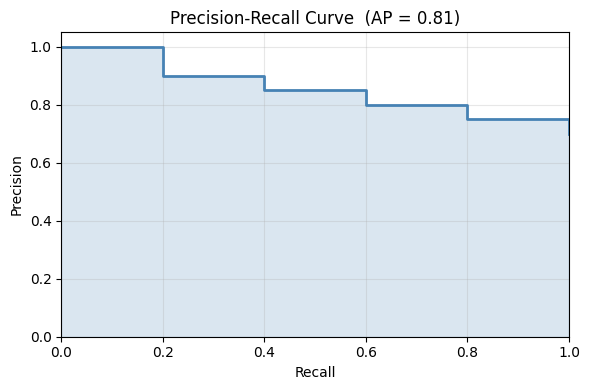

In [17]:
# Recall-Precision pairs from tutorial table
recall_vals    = [0.0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
precision_vals = [1.0, 1.0, 0.9, 0.85, 0.80, 0.75, 0.70]

ap_manual = calculate_ap(precision_vals[1:], recall_vals[1:])
print(f'Manual AP (tutorial example): {ap_manual:.4f}  (expected ≈ 0.81)')

# Plot the PR curve
plt.figure(figsize=(6, 4))
plt.step(recall_vals, precision_vals, where='post', color='steelblue', lw=2)
plt.fill_between(recall_vals, precision_vals, alpha=0.2, color='steelblue', step='post')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve  (AP = {ap_manual:.2f})')
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/pr_curve.png', dpi=150)
plt.show()